# Preprocesamiento — Pronóstico horario de PM2.5 en Montevideo

**Proyecto de Aprendizaje Automático**

Este notebook cubre la etapa de preprocesamiento y el análisis exploratorio. El modelado va aparte.

**Alcance de esta versión:** solo PM2.5. El modelo base es univariante, así que las variables meteorológicas no se preprocesan ni se exportan. Se usan únicamente en el punto 4.5, como diagnóstico de los outliers.

## Orden de las etapas

El orden **no es arbitrario**: cada paso depende del anterior.

| # | Etapa | Por qué va acá |
|---|---|---|
| 1 | Definición del problema | Todo lo demás depende de qué se predice |
| 2 | Índice temporal | Sin índice correcto, los rezagos apuntan a momentos equivocados |
| 3 | Diagnóstico de faltantes | Se **diagnostica**, no se rellena todavía |
| 4 | Outliers de validez | Los valores inválidos pasan a NaN |
| 5 | Imputación | **Después** de los outliers: rellena los huecos originales y los que dejaron los outliers |
| 6 | Partición temporal | Antes de cualquier cosa que aprenda parámetros de los datos |
| 7 | Agregación a horaria | **Después** de outliers: al promediar, un pico espurio se vuelve invisible |
| 8 | Análisis exploratorio | Solo sobre entrenamiento |
| 9 | Exportación | |

**Las tres decisiones de orden que importan:**

- **Imputar va después de quitar outliers.** Un outlier se convierte en NaN, así que si se imputa antes hay que hacerlo dos veces. Peor: la interpolación usa los valores vecinos, y un pico espurio de 3.968 µg/m³ al lado de un hueco contamina todo lo que se rellene.
- **Agregar va después de outliers e imputación.** Al promediar a la hora, un pico espurio de cinco minutos se diluye en un promedio plausible y ya no se puede detectar.
- **Partir va antes de calcular cualquier cosa con los datos.** Si para limpiar o transformar la serie necesitás sacar un número de ella (una media, un percentil, un umbral), ese número tiene que salir solo del tramo de entrenamiento. Si lo calculás con la serie completa, estás usando información del futuro para preparar el pasado, y el modelo va a parecer mejor de lo que es.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

import warnings
warnings.filterwarnings('ignore')

SEMILLA = 2026
rng = np.random.default_rng(SEMILLA)
plt.rcParams['figure.dpi'] = 100

## 1. Definición del problema

| Decisión | Valor |
|---|---|
| Variable objetivo | Concentración de PM2.5, en µg/m³ |
| Frecuencia de trabajo | Horaria |
| Horizonte | 24 pasos = 24 horas |
| Momento de emisión | Cada día a las 00:00, con datos hasta las 23:00 del día anterior |
| Actualización | Diaria |
| Costo del error | Interesa acertar los picos: son los que disparan alertas sanitarias |

La frecuencia original de PM2.5 es por minuto; la de trabajo es horaria. El cambio se hace en el paso 7.

## 2. Carga de datos e índice temporal

| Archivo | Contenido | Resolución original |
|---|---|---|
| `pm25_original.csv` | PM2.5 de Curva de Maroñas y Museo Romántico | por minuto |
| `meteorologia_original.csv` | Meteorología de SUMU (Carrasco) | horaria |

Vienen del warehouse sin agregar, sin imputar, sin grilla completa y sin conversión de unidades. Van separados a propósito: unirlos antes de preprocesar generaría NaN artificiales que contaminarían el diagnóstico de faltantes.

In [ ]:
import os

url_pm25_raw = "https://raw.githubusercontent.com/trajano-carballo/paa-pronostico-pm25-montevideo/main/data/raw/pm25_original.csv.gz"
url_met_raw  = "https://raw.githubusercontent.com/trajano-carballo/paa-pronostico-pm25-montevideo/main/data/raw/meteorologia_original.csv"

df_pm  = pd.read_csv(url_pm25_raw, compression="gzip", parse_dates=["timestamp"])
df_met = pd.read_csv(url_met_raw, parse_dates=["timestamp"])

print(f'PM2.5: {len(df_pm)} filas | Meteorología: {len(df_met)} filas')

PM2.5: 1314267 filas | Meteorología: 20977 filas


### 2.1 Construcción del índice

La marca temporal se convierte a datetime, se ordena y se verifica la frecuencia real; no se asigna por conveniencia.

Sobre la zona horaria: los timestamps traen offset -03 que equivale siempre a America/Montevideo. Se convierte explícitamente para que ambas fuentes queden con la misma zona nombrada y no haya conflictos al unirlas.

In [ ]:
for df in (df_pm, df_met):
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce').dt.tz_convert('America/Montevideo')
    df['faltante'] = df['indicador_valor_faltante'].eq('t')

df_pm = df_pm.sort_values(['estacion', 'timestamp']).reset_index(drop=True)
df_met = df_met.sort_values('timestamp').reset_index(drop=True)

CADENCIA = {'Curva de Maroñas': 60, 'Museo Romántico': 120}   # segundos entre mediciones
ESTACIONES = list(CADENCIA)

print('Zona horaria:', df_pm.timestamp.dt.tz, '|', df_met.timestamp.dt.tz)
print('Fechas no interpretables:', df_pm.timestamp.isna().sum() + df_met.timestamp.isna().sum())

Zona horaria: America/Montevideo | America/Montevideo
Fechas no interpretables: 0


### 2.2 Los cuatro problemas del índice

| Problema | Qué significa |
|---|---|
| Marca inválida | La fecha no se pudo interpretar |
| Duplicado temporal | Dos filas para el mismo instante |
| Hueco temporal | La fila esperada no existe |
| Valor faltante | La fila existe, pero el valor es NaN |

Acá se revisan los dos primeros; los valores faltantes y huecos temporales van en la sección 3.

In [ ]:
print('=== Duplicados temporales ===')
for est, g in df_pm.groupby('estacion'):
    print(f'  {est}: {g.timestamp.duplicated().sum()}')
print(f'  Meteorología: {df_met.timestamp.duplicated().sum()}')

print('\n=== Frecuencia real observada ===')
for est, g in df_pm.groupby('estacion'):
    print(f'  {est}: mediana {g.timestamp.diff().dt.total_seconds().median():.0f} s '
          f'| declarada {CADENCIA[est]} s')
print(f'  Meteorología: mediana {df_met.timestamp.diff().dt.total_seconds().median()/3600:.0f} h')

=== Duplicados temporales ===
  Curva de Maroñas: 0
  Museo Romántico: 0
  Meteorología: 0

=== Frecuencia real observada ===
  Curva de Maroñas: mediana 60 s | declarada 60 s
  Museo Romántico: mediana 120 s | declarada 120 s
  Meteorología: mediana 1 h


## 3. Diagnóstico de valores faltantes

Acá solo se diagnostica. Rellenar viene en el paso 5, después de tratar los outliers.

**Dos tipos de faltante:**
- **Explícitos:** la fila existe pero el warehouse marcó el valor como no utilizable.
- **Implícitos:** no hay fila. No aparecen en `isna()`.

Por eso la completitud se mide contra los registros esperados según la cadencia del sensor, no contra las filas que hay.

In [ ]:
tabla = []
for est, g in df_pm.groupby('estacion'):
    esperados = int((g.timestamp.max() - g.timestamp.min()).total_seconds() // CADENCIA[est]) + 1
    tabla.append({'estacion': est, 'esperados': esperados, 'filas presentes': len(g),
                  'implícitos (sin fila)': esperados - len(g),
                  'explícitos (marcados)': g.faltante.sum(),
                  'válidos': (~g.faltante).sum(),
                  '% completitud': round(100 * (~g.faltante).sum() / esperados, 2)})
pd.DataFrame(tabla).set_index('estacion')

,esperados,filas presentes,implícitos (sin fila),explícitos (marcados),válidos,% completitud
estacion,,,,,,
Curva de Maroñas,1261440,1216750,44690,30742,1186008,94.02
Museo Romántico,104399,97517,6882,57,97460,93.35


### 3.1 Dónde están los faltantes

Un porcentaje global no alcanza: 6 % repartido no es lo mismo que 6 % concentrado en un corte de tres semanas.

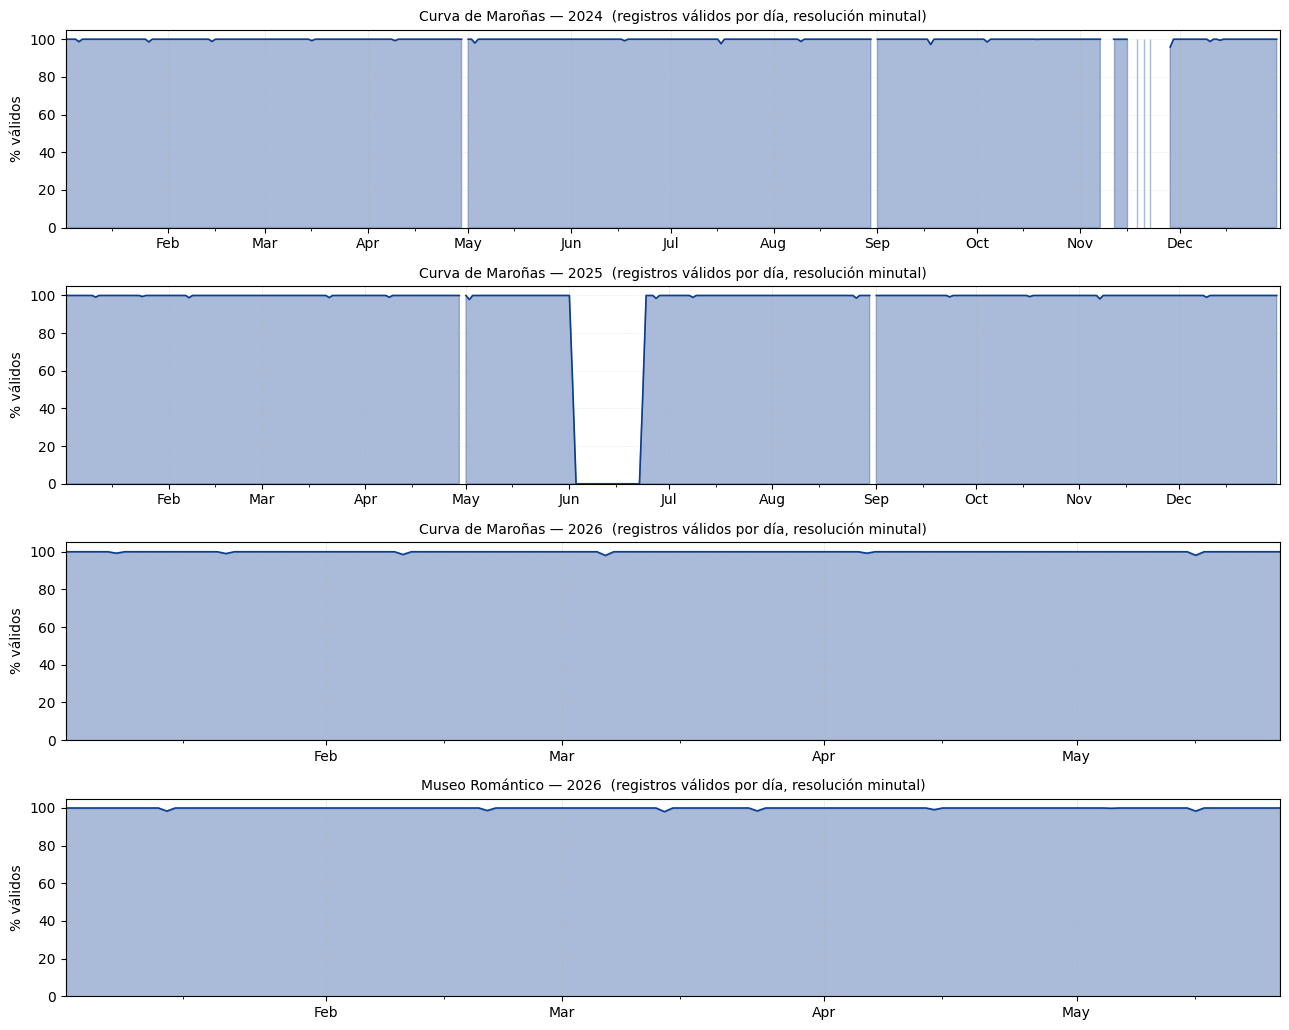

In [ ]:
import matplotlib.dates as mdates
COLOR = '#0b3d91'   # azul marino, buen contraste sobre blanco
AÑOS = {'Curva de Maroñas': [2024, 2025, 2026], 'Museo Romántico': [2026]}
n = sum(len(v) for v in AÑOS.values())
fig, axes = plt.subplots(n, 1, figsize=(13, 2.6 * n))
i = 0
for est in ESTACIONES:
    s = df_pm[df_pm.estacion == est].set_index('timestamp').faltante
    # Cada punto = un día: % de los registros esperados de ese día que son válidos.
    # La serie original es minutal (60 s en Maroñas, 120 s en Museo Romántico);
    # acá solo se resume la disponibilidad por día, no se promedian concentraciones.
    diario = (~s).resample('D').mean() * 100
    for año in AÑOS[est]:
        d = diario[str(año)]
        fin = f'{año}-05-25' if año == 2026 else f'{año}-12-31'
        d = d[:fin]
        ax = axes[i]
        ax.plot(d.index, d.values, lw=1.2, c=COLOR)
        ax.fill_between(d.index, 0, d.values, alpha=0.35, color=COLOR)
        ax.set_title(f'{est} — {año}  (registros válidos por día, resolución minutal)', fontsize=10)
        ax.set_ylabel('% válidos'); ax.set_ylim(0, 105)
        ax.set_xlim(pd.Timestamp(f'{año}-01-01', tz='America/Montevideo'),
                    pd.Timestamp(fin, tz='America/Montevideo'))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        ax.xaxis.set_minor_locator(mdates.DayLocator(bymonthday=[15]))
        ax.grid(axis='x', ls=':', lw=0.6, alpha=0.7)
        ax.grid(axis='y', ls=':', lw=0.5, alpha=0.4)
        i += 1
plt.tight_layout(); plt.show()

**Lectura de las gráficas.** La cobertura es casi total: la mayor parte del tiempo las estaciones registran el 100 % de los minutos esperados. Los faltantes no están repartidos, están concentrados en cortes puntuales.

- **2024:** todo completo salvo algunos días de abril, agosto y noviembre, em este ultimo aparecen varios cortes de uno a seis días seguidos.
- **2025:** un único corte largo, de unas tres semanas en junio. Es el hueco más grande de toda la serie y cae en invierno, la estación de mayor contaminación. Tambien huecos cortos de unos días en abril y agosto.
- **2026:** sin cortes en ninguna de las dos estaciones, en el período disponible (de Enero hasta el 25 de mayo).

### 3.2 Reindexar sobre la grilla completa e inventariar los huecos

Para poder imputar más adelante hay un paso obligatorio: **reindexar sobre la grilla temporal completa**. Los faltantes implícitos no tienen fila, así que hasta que la fila no exista no hay nada que interpolar.

Después se clasifican los huecos por longitud, porque el método que sirve para cinco minutos no es necesariamente el que sirve para tres semanas.

In [ ]:
df_pm['valor_obs'] = df_pm.valor.mask(df_pm.faltante)   # valor observado y utilizable

def reindexar_completo(serie_con_ts, cadencia):
    s = serie_con_ts[~serie_con_ts.index.duplicated()]
    grilla = pd.date_range(s.index.min().floor('min'), s.index.max().ceil('min'),
                           freq=f'{cadencia}s', tz='America/Montevideo')
    return s.reindex(grilla, method='nearest', tolerance=pd.Timedelta(seconds=cadencia / 2))

def inventario(s, unidad_min=1):
    f = s.isna()
    largo = f.groupby((~f).cumsum()).transform('sum').where(f) * unidad_min
    L = largo[f & ~f.shift(1, fill_value=False)]
    etiq = ['≤5 min', '6-15 min', '16-60 min', '1-6 h', '6-24 h', '>24 h']
    cat = pd.cut(L, bins=[0, 5, 15, 60, 360, 1440, 10**9], labels=etiq)
    return pd.DataFrame({'huecos': cat.value_counts().reindex(etiq),
                         'registros': L.groupby(cat, observed=False).sum().reindex(etiq)})

series_obs = {est: reindexar_completo(g.set_index('timestamp').valor_obs, CADENCIA[est])
              for est, g in df_pm.groupby('estacion')}

for est, s in series_obs.items():
    print(f'\n{est}: {len(s)} registros en grilla, {s.isna().sum()} faltantes ({100*s.isna().mean():.1f} %)')
    display(inventario(s, CADENCIA[est] / 60))


Curva de Maroñas: 1261440 registros en grilla, 75432 faltantes (6.0 %)


,huecos,registros
valor_obs,,
≤5 min,895,1518.0
6-15 min,19,207.0
16-60 min,28,739.0
1-6 h,2,158.0
6-24 h,10,12740.0
>24 h,10,60070.0



Museo Romántico: 104400 registros en grilla, 6898 faltantes (6.6 %)


,huecos,registros
valor_obs,,
≤5 min,4988,12134.0
6-15 min,119,824.0
16-60 min,6,204.0
1-6 h,0,0.0
6-24 h,1,634.0
>24 h,0,0.0


## 4. Outliers de validez

Hay dos clases de valor extremo y se tratan distinto:

- **De validez**: error del instrumento. Pasa a NaN y se rellena en el paso 5.
- **Contextual**: episodio real de contaminación. Se conserva, porque es lo que el modelo tiene que aprender a predecir.

El problema es separarlos, porque los dos son valores altos. Lo que los distingue no es la altura sino la forma: un error sube y baja en uno o dos minutos, un episodio real sube y baja a lo largo de horas.

### 4.1 Qué hacen los antecedentes

| Trabajo | Resolución al filtrar | Criterio |
|---|---|---|
| Rakholia et al. (2022) | horaria (promedian los datos minutales antes) | rango válido 0-500 µg/m³; y eliminar lo que supere 200 µg/m³ y triplique las horas previas |
| Zhong et al. (2021) | horaria (su fuente ya entrega datos horarios) | comparar cada hora contra la media móvil de 5 horas; si la diferencia supera 150 µg/m³, se elimina (~3 % de los datos) |

De acá se toman dos cosas: el rango válido de Rakholia, que se aplica en el punto 7.1, y la idea de Zhong de comparar cada valor contra su vecindad en vez de contra toda la serie.

Lo que **no** se copia es el orden ni el estadístico. Los dos filtran sobre serie horaria; nosotros tenemos datos por minuto y filtramos antes de agregar. Los dos motivos están abajo.

In [ ]:
print('Mínimo observado:', df_pm.valor.min())
print('Valores ≤ 0:', (df_pm.valor <= 0).sum(), '(el ETL del warehouse ya los pasa a nulo)')
print('Valores > 1000 µg/m³:', (df_pm.valor > 1000).sum())
df_pm.groupby('estacion').valor.describe(percentiles=[.5, .99, .999]).round(1)

Mínimo observado: 1.0
Valores ≤ 0: 0 (el ETL del warehouse ya los pasa a nulo)
Valores > 1000 µg/m³: 41


,count,mean,std,min,50%,99%,99.9%,max
estacion,,,,,,,,
Curva de Maroñas,1186008.0,12.9,27.3,1.0,6.0,116.0,323.0,3968.0
Museo Romántico,97460.0,7.7,12.6,3.0,3.0,61.0,137.0,353.0


### 4.2 Por qué no se usa el IQR

El criterio clásico marca todo lo que supera `Q3 + 1,5·IQR`. Funciona con distribuciones simétricas; PM2.5 no lo es: la mayoría de los valores son bajos y hay una cola larga de picos **reales**.

In [ ]:
filas = []
for est, g in df_pm.groupby('estacion'):
    v = g.valor.dropna()
    for escala, x in [('original', v), ('log', np.log(v))]:
        q1, q3 = x.quantile([0.25, 0.75])
        for k in (1.5, 3):
            lim = q3 + k * (q3 - q1)
            lim_ug = np.exp(lim) if escala == 'log' else lim
            filas.append({'estacion': est, 'escala': escala, 'k': k,
                          'límite (µg/m³)': round(lim_ug, 1),
                          '% marcados': round(100 * (v > lim_ug).mean(), 2)})
pd.DataFrame(filas).set_index(['estacion', 'escala', 'k'])

límite (µg/m³)  % marcados
estacion         escala   k                              
Curva de Maroñas original 1.5            25.5       10.75
                          3.0            39.0        6.14
                 log      1.5            96.0        1.48
                          3.0           768.0        0.01
Museo Romántico  original 1.5            15.5        8.13
                          3.0            23.0        4.48
                 log      1.5            34.8        2.59
                          3.0           151.7        0.07

En escala original el IQR marca cerca del **11 %** de las mediciones, incluidos días enteros de invierno con contaminación real. Es inservible.

### 4.3 Criterio adoptado

Para cada minuto se mira una ventana de 31 minutos a su alrededor y se calcula la **mediana** de esa ventana. Si el valor se aparta más de 6 desviaciones robustas de esa mediana **y** además supera los 300 µg/m³, se marca como inválido y pasa a NaN. Si no cumple las dos condiciones, se conserva.

Esto es un filtro de Hampel. La lógica de comparar contra la vecindad local viene de Zhong et al. (2021); la diferencia es que ellos usan la media de la ventana y acá se usa la mediana. El punto 4.3.1 muestra por qué.

**Por qué funciona.** Cuando un episodio real llega a su pico, sus vecinos también están altos, así que el valor no se despega de la ventana y se conserva. Un error del sensor aparece rodeado de valores normales, se despega, y se marca.

Por qué se filtra antes de agregar a horaria. Rakholia et al. (2022) también partían de registros minutales, pero promediaban a frecuencia horaria antes de aplicar sus criterios de outliers. Acá se invierte ese orden: se filtra primero y se agrega después. La razón es que un pico de dos minutos no desaparece al promediar, se reparte en el valor horario y lo levanta. Filtrando antes, ese pico se detecta y se descarta cuando todavía se ve entero, en vez de esperar a que quede diluido y camuflado dentro de un promedio.
La celda siguiente muestra esto sobre un episodio real de la serie.

Un detalle a declarar: la ventana usa 15 minutos antes y 15 después del punto evaluado. Acá no es problema, porque ya tenemos toda la serie completa. En un sistema en vivo el "después" todavía no existiría, pero ese no es nuestro caso.

In [ ]:
def detectar_outliers(serie):
    """Filtro de Hampel: marca un minuto como inválido si se aparta mucho de la mediana
    de su ventana local (31 min) y además supera el piso de 300 µg/m³."""
    mediana_local = serie.rolling(VENTANA, center=True, min_periods=5).median()
    desvio_local = (serie - mediana_local).abs().rolling(VENTANA, center=True, min_periods=5).median()
    # 1.4826 convierte el MAD en un equivalente al desvío estándar
    se_aparta = (serie - mediana_local).abs() > K * 1.4826 * desvio_local.clip(lower=1)
    return se_aparta & (serie > MINIMO)


VENTANA, K, MINIMO = '31min', 6, 300   # ventana de 31 min, 6 desvíos, piso 300 µg/m³

mascaras_outlier, series_limpias = {}, {}
for est, s in series_obs.items():
    m = detectar_outliers(s)
    mascaras_outlier[est] = m               # True donde el minuto es inválido
    series_limpias[est] = s.mask(m)         # el outlier pasa a NaN
    print(f'{est}: {m.sum()} outliers ({100*m.mean():.3f} %) | '
          f'máx antes {s.max():.0f} → después {series_limpias[est].max():.0f}')

Curva de Maroñas: 225 outliers (0.018 %) | máx antes 3968 → después 2256
Museo Romántico: 0 outliers (0.000 %) | máx antes 353 → después 353


In [ ]:
# ¿Cuánto levanta un pico de dos minutos al promedio horario en el que cae?
# Compara el promedio de esa hora con y sin el pico, usando el episodio más alto marcado.

s = series_obs['Curva de Maroñas']
mascara = mascaras_outlier['Curva de Maroñas']

hora_pico = s[mascara].idxmax().floor('h')                          # hora del pico más alto marcado
minutos_hora = s.loc[hora_pico:hora_pico + pd.Timedelta('59min')]   # los 60 minutos de esa hora

promedio_con_pico = minutos_hora.mean()                              # como quedaría si no se filtra antes
promedio_sin_pico = minutos_hora[~mascara.loc[minutos_hora.index]].mean()   # filtrando primero

print(f'Hora: {hora_pico}')
print(f'Pico marcado: {minutos_hora.max():.0f} µg/m³')
print(f'Promedio horario CON el pico adentro: {promedio_con_pico:.1f} µg/m³')
print(f'Promedio horario SIN el pico (filtrado antes): {promedio_sin_pico:.1f} µg/m³')
print(f'Diferencia: {promedio_con_pico - promedio_sin_pico:.1f} µg/m³')

Hora: 2025-03-20 02:00:00-03:00
Pico marcado: 3968 µg/m³
Promedio horario CON el pico adentro: 383.4 µg/m³
Promedio horario SIN el pico (filtrado antes): 115.7 µg/m³
Diferencia: 267.8 µg/m³


#### 4.3.1 ¿Por qué mediana y no media?

El problema de usar la media es que el propio valor raro entra en el cálculo de la referencia contra la que se lo compara, y la corre hacia arriba. Cuanto más extremo el valor, más corre la referencia, y menos anómalo parece.

La celda de abajo repite la detección cambiando solo el estadístico de la ventana, para ver qué pasa con nuestros datos.

In [ ]:
# Un outlier puntual, aislado, sin vecinos altos alrededor

s = series_obs['Curva de Maroñas']
m = mascaras_outlier['Curva de Maroñas']

pico_aislado = None
for t in s[m].index:
    contexto = s.loc[t - pd.Timedelta('15min'):t + pd.Timedelta('15min')].drop(t)
    if contexto.max() < 200:
        pico_aislado = t
        break

if pico_aislado is None:
    print('No se encontró ningún outlier con vecinos por debajo del umbral.')
else:
    w = s.loc[pico_aislado - pd.Timedelta('15min'):pico_aislado + pd.Timedelta('15min')]
    sin_pico = w.drop(pico_aislado)
    print(f'Pico aislado: {s[pico_aislado]:.0f} µg/m³ el {pico_aislado:%Y-%m-%d %H:%M}')
    print(f'  Media de la ventana:   {sin_pico.mean():6.1f} sin el pico → {w.mean():6.1f} con el pico')
    print(f'  Mediana de la ventana: {sin_pico.median():6.1f} sin el pico → {w.median():6.1f} con el pico')

Pico aislado: 335 µg/m³ el 2024-05-06 15:56
  Media de la ventana:     34.9 sin el pico →   44.6 con el pico
  Mediana de la ventana:    8.0 sin el pico →    8.0 con el pico


###Sobre un pico aislado de 335 µg/m³, la media de la ventana se corrió casi 10 µg/m³ y la mediana no se movió.

**Lectura.** El pico mueve la media de su propia ventana varias decenas de µg/m³ y a la mediana prácticamente no la mueve. Con media y desvío el criterio marca menos valores, porque el outlier infla las dos cosas que se usan para medirlo.

Suponemos entonces que para nuestros datos, a resolución minutal y con picos de esta magnitud, la media móvil no es una referencia confiable. Por eso se usa mediana y MAD. A Zhong esto le afecta mucho menos porque trabaja sobre serie horaria, donde un promedio de 60 mediciones ya diluyó cualquier pico de un minuto.

### 4.4 Cantidad de outliers y sus valores próximos

La altura del pico sola no dice la causa. Un valor alto aislado sugiere falla del instrumento; uno dentro de una subida sostenida podría sugerir un evento real. Se mira el contexto de ±60 minutos.

In [ ]:
UMBRAL_EVENTO, VENTANA_CTX = 1000, 60

ext = df_pm[df_pm.valor > UMBRAL_EVENTO].sort_values(['estacion', 'timestamp'])
nuevo = (ext.estacion != ext.estacion.shift()) | (ext.timestamp.diff() > pd.Timedelta('30min'))
ext = ext.assign(episodio=nuevo.cumsum())

resumen = []
for ep, e in ext.groupby('episodio'):
    est, t0, t1 = e.estacion.iloc[0], e.timestamp.min(), e.timestamp.max()
    s = series_obs[est]
    antes = s[t0 - pd.Timedelta(minutes=VENTANA_CTX):t0 - pd.Timedelta(minutes=1)]
    despues = s[t1 + pd.Timedelta(minutes=1):t1 + pd.Timedelta(minutes=VENTANA_CTX)]
    resumen.append({'estacion': est, 'inicio': t0, 'duracion_min': len(e), 'pico': e.valor.max(),
                    'mediana 60min antes': antes.median(), 'mediana 60min después': despues.median(),
                    'pico/mediana antes': round(e.valor.max() / antes.median(), 1) if antes.notna().any() else np.nan})
resumen = pd.DataFrame(resumen)
print(f'{len(ext)} minutos por encima de {UMBRAL_EVENTO} µg/m³ en {len(resumen)} episodios')
resumen

41 minutos por encima de 1000 µg/m³ en 10 episodios


,estacion,inicio,duracion_min,pico,mediana 60min antes,mediana 60min después,pico/mediana antes
0,Curva de Maroñas,2024-07-01 23:50:00-03:00,1,1004.0,200.0,471.5,5.0
1,Curva de Maroñas,2024-09-05 22:56:00-03:00,2,1409.0,41.5,144.5,34.0
2,Curva de Maroñas,2025-01-14 21:32:00-03:00,2,2007.0,13.0,32.0,154.4
3,Curva de Maroñas,2025-02-23 12:06:00-03:00,1,1560.0,10.0,11.0,156.0
4,Curva de Maroñas,2025-03-20 02:30:00-03:00,5,3968.0,13.5,10.0,293.9
5,Curva de Maroñas,2025-03-20 04:41:00-03:00,3,1439.0,134.0,211.5,10.7
6,Curva de Maroñas,2025-03-20 06:16:00-03:00,22,2256.0,111.5,16.0,20.2
7,Curva de Maroñas,2025-08-17 17:17:00-03:00,1,1550.0,41.5,75.5,37.3
8,Curva de Maroñas,2025-08-29 00:38:00-03:00,3,1253.0,5.0,15.5,250.6
9,Curva de Maroñas,2026-01-17 19:45:00-03:00,1,1530.0,37.0,14.0,41.4


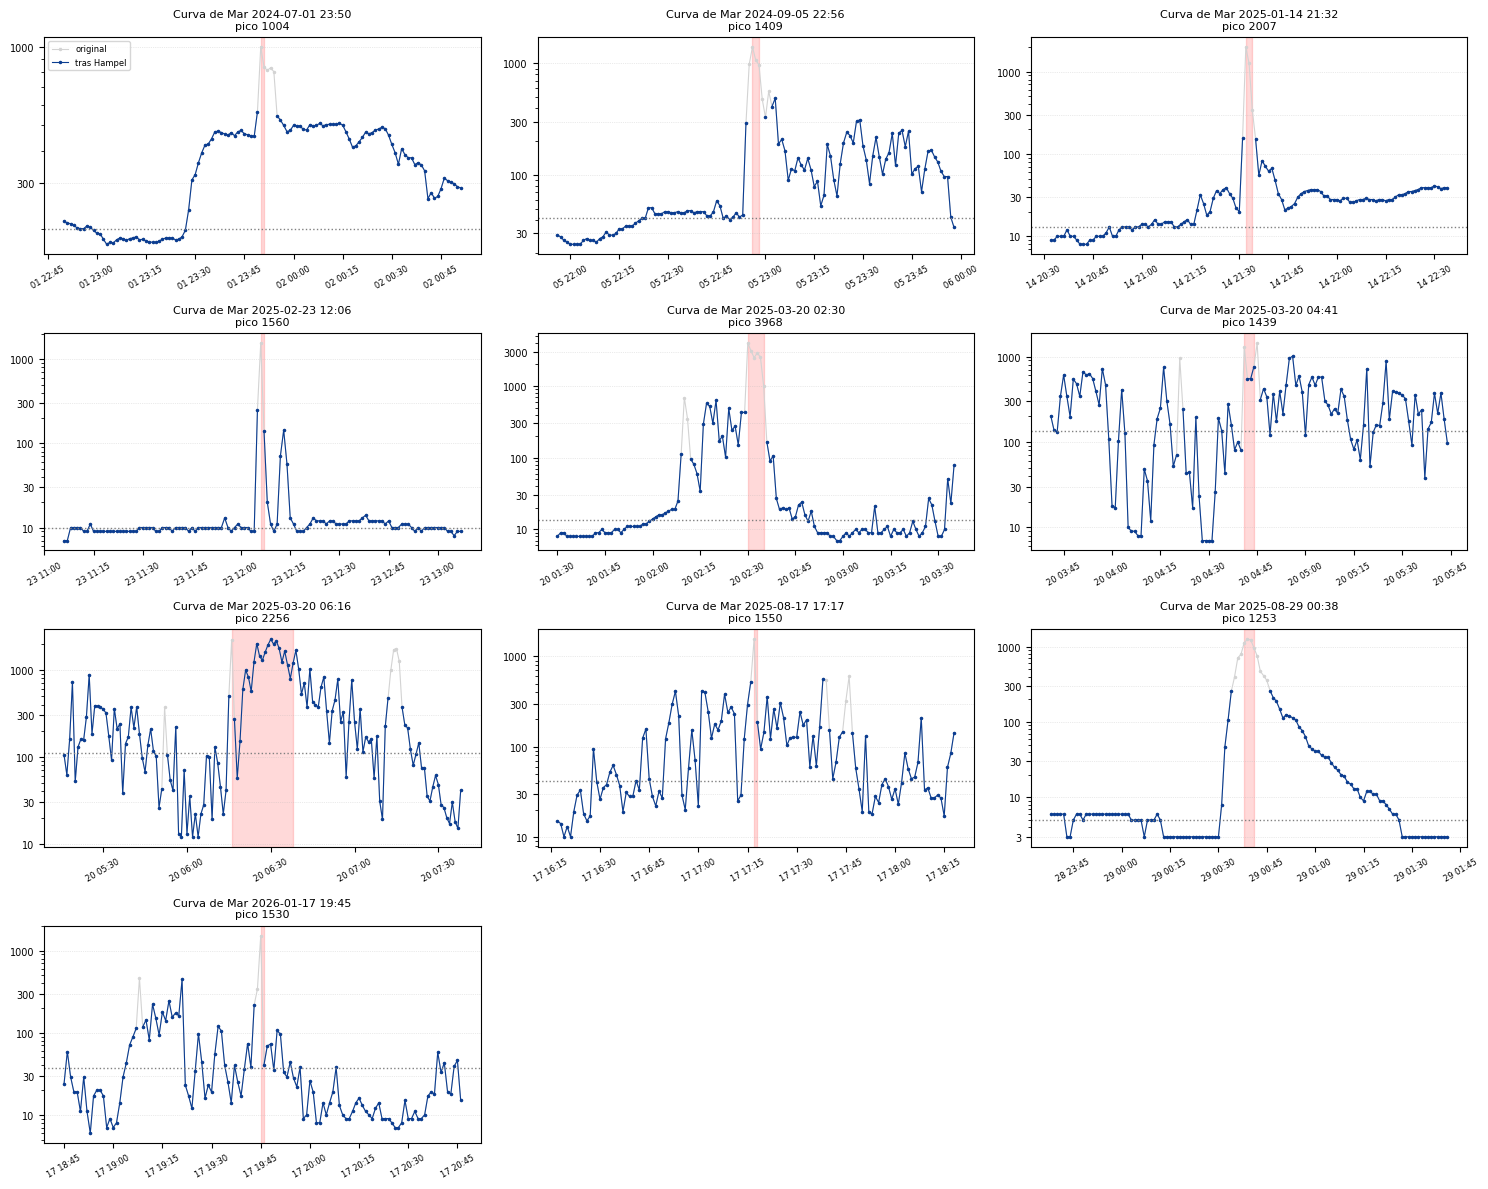

In [ ]:
import matplotlib.ticker as mticker

n = len(resumen); cols = 3; filas_g = int(np.ceil(n / cols))
fig, axes = plt.subplots(filas_g, cols, figsize=(15, 3 * filas_g), squeeze=False)
for i, (ax, (_, r)) in enumerate(zip(axes.flat, resumen.iterrows())):
    s = series_obs[r.estacion]
    t1 = r.inicio + pd.Timedelta(minutes=int(r.duracion_min))
    w = s[r.inicio - pd.Timedelta(minutes=VENTANA_CTX):t1 + pd.Timedelta(minutes=VENTANA_CTX)]

    # Serie original en gris y, encima, la que queda tras Hampel:
    # donde solo se ve el gris, el filtro eliminó ese minuto
    ax.plot(w.index, w, marker='.', ms=3, lw=0.8, c='lightgray', label='original')
    wl = series_limpias[r.estacion].reindex(w.index)
    ax.plot(wl.index, wl, marker='.', ms=3, lw=0.8, c='#0b3d91', label='tras Hampel')

    ax.axvspan(r.inicio, t1, color='r', alpha=0.15)
    ax.axhline(r['mediana 60min antes'], c='gray', ls=':', lw=1)
    ax.set_yscale('log')
    # Marcas en valores redondos de µg/m³ en vez de notación científica
    ax.yaxis.set_major_locator(mticker.FixedLocator([3, 10, 30, 100, 300, 1000, 3000]))
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.grid(axis='y', ls=':', lw=0.5, alpha=0.5)
    ax.set_title(f'{r.estacion[:12]} {r.inicio:%Y-%m-%d %H:%M}\npico {r.pico:.0f}', fontsize=8)
    ax.tick_params(axis='x', labelsize=6, rotation=30)
    ax.tick_params(axis='y', labelsize=7)
    if i == 0:
        ax.legend(fontsize=6, loc='upper left')
for ax in axes.flat[n:]: ax.axis('off')
plt.tight_layout(); plt.show()

**Qué hacemos con los dos casos graduales.** Los dejamos como están. Pueden ser humo real o una falla del sensor, y no hay forma de saberlo sin conocer la marca y el rango de error del equipo, que la red de monitoreo no publica.

De todas formas ninguno queda sin tratar: el del 2025-03-20 06:16 es la única hora que supera los 500 µg/m³, así que el criterio del punto 7.1 lo pasa a faltante.
Los dejamos anotados acá para que quede claro por qué se tomó esta decisión.

###4.5 ¿Explica el viento los outliers?

Antes de dar por inválido un pico conviene revisar la meteorología del momento: si había viento fuerte, el valor podría corresponder a material levantado del suelo, un fenómeno real y no un error del sensor.

La relación habitual entre viento y PM2.5 es de dilución: más viento, menos concentración. Lo vimos en el proyecto de ingeniería de datos, con una correlación de -0,507 sobre promedios diarios. Acá se revisa si los picos marcados son una excepción a eso.

Se comparan tres grupos de horas: las que tienen algún minuto marcado por Hampel, las que tienen un pico alto que el filtro no tocó, y el resto.

In [ ]:
from scipy.stats import mannwhitneyu

ESTACION_ANALISIS = 'Curva de Maroñas'   # única estación con dos años completos
UMBRAL_EXTREMO = 300                     # mismo piso que usa Hampel, para comparar grupos altos entre sí
VIENTO_FUERTE, VIENTO_CALMO = 12, 3      # nudos; umbrales físicos fijados a priori, no ajustados a estos datos

s_obs = series_obs[ESTACION_ANALISIS]
s_lim = series_limpias[ESTACION_ANALISIS]
mascara = mascaras_outlier[ESTACION_ANALISIS]

# PM2.5 a horaria, guardando el pico antes y después de limpiar
pm_h = pd.DataFrame({'pm25_max': s_obs.resample('h').max(),
                     'pm25_max_limpio': s_lim.resample('h').max(),
                     'n_outliers': mascara.resample('h').sum()})

met = df_met.set_index('timestamp').sort_index()
met.loc[met.faltante, 'velocidad_viento_nudos'] = np.nan      # lo que el warehouse marcó no entra
viento = met.velocidad_viento_nudos.resample('h').mean()      # ya es horaria; asegura grilla regular

d = pm_h.join(viento, how='inner')

# Tres grupos de horas. Si una hora tiene outlier y además un pico que sobrevive, prima "marcada"
es_outlier = d.n_outliers > 0
sobrevive = d.pm25_max_limpio >= UMBRAL_EXTREMO
d['grupo'] = np.select([es_outlier, sobrevive],
                       ['Pico marcado por Hampel', 'Extremo conservado'], default='Hora normal')
ORDEN = ['Hora normal', 'Extremo conservado', 'Pico marcado por Hampel']

v = d.velocidad_viento_nudos
tabla = pd.DataFrame({
    'n horas': d.grupo.value_counts().reindex(ORDEN),
    'viento mediano (nudos)': d.groupby('grupo').velocidad_viento_nudos.median().reindex(ORDEN).round(1),
    f'% con viento ≥ {VIENTO_FUERTE}': (v >= VIENTO_FUERTE).where(v.notna()).groupby(d.grupo).mean().reindex(ORDEN).mul(100).round(1),
    f'% con viento < {VIENTO_CALMO}': (v < VIENTO_CALMO).where(v.notna()).groupby(d.grupo).mean().reindex(ORDEN).mul(100).round(1)})
display(tabla)

# Cuántas veces más frecuente es el viento fuerte en los picos marcados que en una hora normal
base = tabla.loc['Hora normal', f'% con viento ≥ {VIENTO_FUERTE}']
print(f'Viento fuerte en picos marcados vs hora normal: '
      f'{tabla.loc["Pico marcado por Hampel", f"% con viento ≥ {VIENTO_FUERTE}"] / base:.2f}x')


def cliffs_delta(x, y):
    """Tamaño de efecto no paramétrico: +1 si x siempre supera a y, 0 si se solapan."""
    x, y = np.asarray(x), np.asarray(y)
    return (np.sum(x[:, None] > y) - np.sum(x[:, None] < y)) / (len(x) * len(y))


# Mann-Whitney: no asume normalidad, y la velocidad del viento es asimétrica
a = d.loc[d.grupo == 'Pico marcado por Hampel', 'velocidad_viento_nudos'].dropna()
b = d.loc[d.grupo == 'Hora normal', 'velocidad_viento_nudos'].dropna()
if len(a) >= 5:
    _, pv = mannwhitneyu(a, b, alternative='two-sided')
    delta = cliffs_delta(a.values, b.values)
    efecto = ('despreciable' if abs(delta) < .147 else 'pequeño' if abs(delta) < .33
              else 'moderado' if abs(delta) < .474 else 'grande')
    print(f'Mann-Whitney marcados vs normales: p = {pv:.4f} | delta de Cliff = {delta:.3f} ({efecto})')
else:
    print(f'Solo {len(a)} horas con outlier: muestra insuficiente para contrastar.')


,n horas,viento mediano (nudos),% con viento ≥ 12,% con viento < 3
grupo,,,,
Hora normal,20891,7.0,18.705001,18.949794
Extremo conservado,49,0.0,0.0,73.469388
Pico marcado por Hampel,84,2.0,2.380952,53.571429


Viento fuerte en picos marcados vs hora normal: 0.13x
Mann-Whitney marcados vs normales: p = 0.0000 | delta de Cliff = -0.512 (grande)


**Conclusión.** El viento no distingue a los picos marcados del resto de las horas. Y aunque explicara algún caso suelto, no los explica a todos: aplicar una excepción solo a los que encajan sería un criterio que cambia según el caso, imposible de sostener.

Por eso **no se usa ninguna variable meteorológica en el criterio de eliminación**. El punto 4.3 queda como está.

Dos límites de este chequeo: el viento es de Carrasco, a kilómetros de la estación, y es un promedio horario mientras que los picos duran minutos, así que una ráfaga local puede no aparecer. Y el material que levanta el viento es sobre todo partícula gruesa (PM10), no la fracción fina que se mide acá.

## 5. Imputación

Ahora sí se rellenan los huecos, e incluyen tanto los faltantes originales como los NaN que dejaron los outliers del paso anterior. **El objetivo es completar el dataset entero: huecos cortos y largos.**

### 5.1 ¿Lineal o cuadrática?

Para elegir no alcanza con mirar el resultado: hay que saber cuánto se equivoca cada una. Y se puede medir.

**La idea:** agarramos un tramo de la serie que está completo, le borramos un pedazo a propósito, lo rellenamos con cada método y comparamos contra los valores que borramos. Como esos valores los conocemos, sabemos exactamente cuánto erró cada uno.

Esto se repite con huecos de varios tamaños (5 minutos, 30 minutos, 2 horas, 12 horas, 2 días, 7 días), porque lo que sirve para un hueco chico puede ser pésimo para uno grande. El error se mide con el MAE: el promedio de cuánto se desvió cada valor imputado del real.

Para leer el MAE conviene compararlo con el promedio de la serie (unos 13 µg/m³): si el error es parecido a ese número, el método no aporta nada.

Después se controla que la imputación **no cambie la distribución** de los datos, que es la otra cara del mismo problema: si al rellenar la serie cambia de forma, estamos metiendo valores que no se parecen a los reales.

In [ ]:
LARGOS = [5, 30, 120, 720, 2880, 10080]   # 5 min, 30 min, 2 h, 12 h, 2 d, 7 d
N_REPS = 25

def etiqueta(L):
    return f'{L} min' if L < 60 else (f'{L//60} h' if L < 1440 else f'{L//1440} d')

def benchmark(serie, largos, ctx_max, n=N_REPS, etiq=etiqueta):
    filas = []
    for L in largos:
        ctx = max(3, min(L, ctx_max))
        total = L + 2 * ctx
        # se admite hasta 5 % de faltantes previos; el error se mide solo sobre lo conocido
        ok = serie.notna().rolling(total, min_periods=total).mean() >= 0.95
        cand = np.flatnonzero(ok.values)
        if len(cand) < 5:
            filas.append({'hueco': etiq(L), 'casos': 0}); continue
        elegidos = rng.choice(cand, size=min(n, len(cand)), replace=False)
        err = {'lineal': [], 'cuadrática': []}
        for fin in elegidos:
            tramo = serie.iloc[fin - total:fin].copy()
            verdad = tramo.iloc[ctx:ctx + L].copy()
            hueco = tramo.copy(); hueco.iloc[ctx:ctx + L] = np.nan
            for nombre, metodo in [('lineal', 'linear'), ('cuadrática', 'quadratic')]:
                pred = hueco.interpolate(method=metodo, limit_area='inside').iloc[ctx:ctx + L]
                err[nombre].append((pred - verdad).abs().mean())
        filas.append({'hueco': etiq(L), 'casos': len(elegidos),
                      **{f'MAE {k}': round(np.mean(v), 2) for k, v in err.items()}})
    return pd.DataFrame(filas).set_index('hueco')

# Solo entrenamiento (hasta 2025-12-31): la elección de método no debe apoyarse
# en el tramo que después se usa como validación temporal (2026 en adelante).
# Solo Curva de Maroñas: Museo Romántico no tiene tramos completos lo bastante
# largos para la prueba.
s_train = series_limpias['Curva de Maroñas'].loc[:'2025-12-31 23:59:59']
print(f'Curva de Maroñas — solo entrenamiento (nivel medio {s_train.mean():.1f} µg/m³)')
display(benchmark(s_train, LARGOS, ctx_max=1440))

Curva de Maroñas — solo entrenamiento (nivel medio 13.3 µg/m³)


,casos,MAE lineal,MAE cuadrática
hueco,,,
5 min,25,0.94,1.08
30 min,25,1.43,5.04
2 h,25,2.34,23.21
12 h,25,6.94,104.88
2 d,25,12.84,476.82
7 d,25,12.48,2113.02


**Resultado.** La lineal gana en todas las longitudes. La cuadrática se descontrola con huecos grandes: en 7 días llega a un MAE de 1.898, cuando el nivel medio de la serie es 12,8.

El benchmark se corre solo sobre Curva de Maroñas

Se usará interpolación lineal en todos los huecos.

### 5.2 Aplicación

La cuadrática pierde en todas las longitudes y se descontrola con huecos largos: proyecta la curvatura de los bordes hacia adentro y genera valores absurdos. Queda descartada.

Se usa interpolación lineal en todos los huecos. No aprende nada de los datos (solo une dos puntos conocidos con una recta), así que puede aplicarse a toda la serie sin riesgo de fuga de información.

In [ ]:
def imputar_todo(serie):
    """Rellena todos los huecos con interpolación lineal.
    ffill/bfill cubre los bordes, donde no hay dos puntos entre los cuales interpolar."""
    return serie.interpolate(method='linear', limit_area='inside').ffill().bfill()

series_llenas = {}
for est, s in series_limpias.items():
    series_llenas[est] = imputar_todo(s)
    print(f'{est}: {s.isna().sum()} faltantes → {series_llenas[est].isna().sum()} restantes')

Curva de Maroñas: 75657 faltantes → 0 restantes
Museo Romántico: 6898 faltantes → 0 restantes


### 5.3 ¿La imputación cambia la distribución de los datos?

Este es el control de calidad. Si al rellenar la distribución se mueve, estamos metiendo valores que no se parecen a los reales y el modelo aprendería de datos inventados.

Se revisa de tres formas:

- **Estadísticos** antes y después: media, desvío, mediana, percentil 95.
- **Prueba de Kolmogorov-Smirnov (KS)**: compara las dos distribuciones completas y devuelve un estadístico entre 0 y 1. **Cuanto más cerca de 0, más parecidas.** El p-valor es sensible al tamaño de muestra (con un millón de datos casi siempre da significativo), así que lo que importa es el estadístico.
- **Gráficos**: distribución completa, distribución de los valores imputados por separado, y acumulada (ECDF). Si las curvas de la ECDF se superponen, la distribución no cambió.

El gráfico del medio compara los valores imputados contra los observados. Si tienen una forma parecida, la imputación es creíble. Si los imputados quedan todos concentrados en un mismo valor, significa que el método aplanó la serie.

In [ ]:
def comparar_distribucion(observado, imputado, nombre=''):
    obs, imp = observado.dropna(), imputado.dropna()
    ks = ks_2samp(obs, imp)
    return {'serie': nombre, 'n imputado': int(observado.isna().sum()),
            'media obs': round(obs.mean(), 2), 'media final': round(imp.mean(), 2),
            'std obs': round(obs.std(), 2), 'std final': round(imp.std(), 2),
            'p50 obs': round(obs.median(), 2), 'p50 final': round(imp.median(), 2),
            'p95 obs': round(obs.quantile(.95), 2), 'p95 final': round(imp.quantile(.95), 2),
            'KS': round(ks.statistic, 4)}

METODOS_COMP, filas = {}, []
for est, s in series_limpias.items():
    METODOS_COMP[est] = {
        'lineal (elegido)': series_llenas[est],
        'cuadrática': s.interpolate(method='quadratic', limit_area='inside').ffill().bfill(),
    }
    for nombre, serie in METODOS_COMP[est].items():
        filas.append({'estacion': est, **comparar_distribucion(s, serie, nombre)})

pd.DataFrame(filas).set_index(['estacion', 'serie'])

n imputado  media obs  media final  \
estacion         serie                                                  
Curva de Maroñas lineal (elegido)       75657      12.83        12.65   
                 cuadrática             75657      12.83       253.22   
Museo Romántico  lineal (elegido)        6898       7.70         7.68   
                 cuadrática              6898       7.70         7.22   

                                   std obs  std final  p50 obs  p50 final  \
estacion         serie                                                      
Curva de Maroñas lineal (elegido)    25.23      24.86      6.0        6.0   
                 cuadrática          25.23    1613.08      6.0        6.0   
Museo Romántico  lineal (elegido)    12.60      12.52      3.0        3.0   
                 cuadrática          12.60      16.19      3.0        3.0   

                                   p95 obs  p95 final      KS  
estacion         serie                                         
Curva de Maroñas lineal (elegido)     45.0      45.00  0.0189  
                 cuadrática           45.0     133.68  0.0438  
Museo Romántico  lineal (elegido)     22.0      22.00  0.0029  
                 cuadrática           22.0      22.00  0.0153

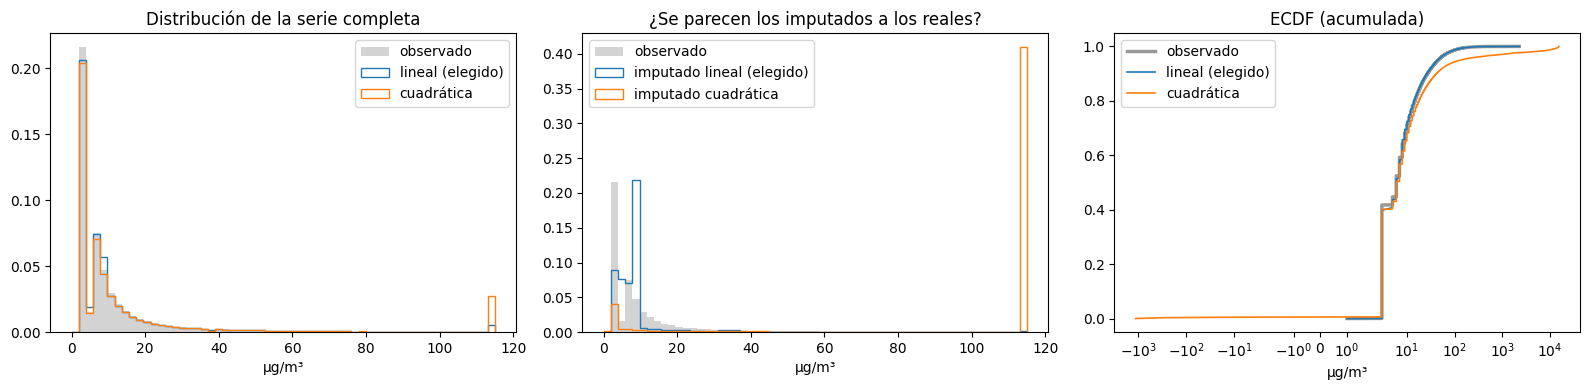

In [ ]:
est = 'Curva de Maroñas'
obs = series_limpias[est]
tope = obs.quantile(0.99)
bins = np.linspace(0, tope, 60)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(obs.dropna(), bins=bins, density=True, color='lightgray', label='observado')
for nombre, serie in METODOS_COMP[est].items():
    axes[0].hist(serie.clip(upper=tope), bins=bins, density=True, histtype='step', lw=1.5, label=nombre)
axes[0].set_title('Distribución de la serie completa'); axes[0].set_xlabel('µg/m³'); axes[0].legend()

axes[1].hist(obs.dropna(), bins=bins, density=True, color='lightgray', label='observado')
for nombre, serie in METODOS_COMP[est].items():
    axes[1].hist(serie[obs.isna()].clip(-tope, tope), bins=bins, density=True,
                 histtype='step', lw=1.5, label=f'imputado {nombre}')
axes[1].set_title('¿Se parecen los imputados a los reales?'); axes[1].set_xlabel('µg/m³'); axes[1].legend()

def ecdf(x):
    x = np.sort(x.dropna().values)
    return x, np.arange(1, len(x) + 1) / len(x)

x, y = ecdf(obs); axes[2].plot(x, y, c='k', lw=2.5, alpha=.4, label='observado')
for nombre, serie in METODOS_COMP[est].items():
    x, y = ecdf(serie); axes[2].plot(x, y, lw=1.2, label=nombre)
axes[2].set_xscale('symlog'); axes[2].set_title('ECDF (acumulada)')
axes[2].set_xlabel('µg/m³'); axes[2].legend()
plt.tight_layout(); plt.show()

Los gráficos confirman la tabla. En los dos primeros paneles se ve el problema de la cuadrática de forma directa: en vez de una distribución continua, aparece una masa de valores amontonada cerca de 117 µg/m³, sin correlato real. Es lo que arma su media de 253,22: no son valores "un poco altos", es un grupo entero de imputaciones fuera de lugar.

La curva lineal, en cambio, sigue de cerca la forma de los observados en los tres gráficos, y en la ECDF prácticamente se superpone con ella.

Con esto se confirma: se usa interpolación lineal.

  ## 6. Partición temporal

> Reservar el tramo final **antes** de ejecutar cualquier procedimiento que estime parámetros a partir de los valores.

| Partición | Estación | Período | Para qué |
|---|---|---|---|
| Entrenamiento | Curva de Maroñas | 2024-01-01 → 2025-12-31 | Aprender |
| Validación temporal | Curva de Maroñas | 2026-01-01 → 2026-05-25 | ¿Generaliza a un período posterior? |
| Validación espacial | Museo Romántico | 2026-01-01 → 2026-05-25 | ¿Generaliza a otra ubicación sin reentrenar? |

El corte del 25 de mayo de 2026 no es arbitrario: Curva de Maroñas interrumpe el monitoreo útil a partir del 26.

**Qué se pudo hacer antes de partir:** revisión del índice, reglas físicas, filtro local de Hampel e interpolación lineal (no aprende nada).

**Qué solo con entrenamiento de acá en adelante:** escaladores, codificadores, selección de lags, modelos e hiperparámetros.

**Sesgo a declarar:** las particiones de 2026 cubren solo enero a mayo, sin invierno, que es la estación de mayor contaminación. Una diferencia de métricas entre entrenamiento y validación mezcla corrimiento temporal real con sesgo de cobertura estacional.

In [ ]:
FIN_TRAIN = pd.Timestamp('2026-01-01', tz='America/Montevideo')

## 7. Agregación a frecuencia horaria

Recién ahora se pasa de minutal a horaria, con la serie ya limpia de outliers y completa.

**Tres decisiones:**

- **Ventana y etiqueta:** cada hora abarca `[HH:00, HH:59]` y se etiqueta con su inicio. Así ninguna fila contiene información posterior a su propia etiqueta, que en pronóstico sería fuga.
- **Grilla horaria continua:** se reindexa sobre todas las horas del período.
- **Completitud observada:** como la serie ya está imputada, todas las horas tienen 60 valores. Por eso se calcula aparte qué fracción de cada hora proviene de mediciones reales, y se guarda como columna. No se usa para descartar horas (el dataset se quiere completo), pero permite identificar las horas mayormente sintéticas al analizar resultados.

In [ ]:
horarias = []
for est in ESTACIONES:
    lleno, obs = series_llenas[est], series_limpias[est]
    pm25 = lleno.resample('h', closed='left', label='left').mean()
    reales = obs.notna().resample('h', closed='left', label='left').mean()   # fracción observada

    h = pd.DataFrame({'pm25': pm25, 'completitud_observada': reales})
    grilla = pd.date_range(h.index.min(), h.index.max(), freq='h', tz='America/Montevideo')
    h = h.reindex(grilla)
    h['pm25'] = h.pm25.interpolate(method='linear', limit_area='inside').ffill().bfill()
    h['completitud_observada'] = h.completitud_observada.fillna(0)
    h['estacion'] = est
    horarias.append(h)
    print(f'{est}: {len(h)} horas | 100 % observada: {(h.completitud_observada == 1).sum()} '
          f'| totalmente imputada: {(h.completitud_observada == 0).sum()}')

df_h = pd.concat(horarias)
df_h.index.name = 'timestamp'
df_h.head()

Curva de Maroñas: 21024 horas | 100 % observada: 18774 | totalmente imputada: 1201
Museo Romántico: 3480 horas | 100 % observada: 275 | totalmente imputada: 9


,pm25,completitud_observada,estacion
timestamp,,,
2024-01-01 00:00:00-03:00,42.783333,1.0,Curva de Maroñas
2024-01-01 01:00:00-03:00,11.166667,1.0,Curva de Maroñas
2024-01-01 02:00:00-03:00,7.500000,1.0,Curva de Maroñas
2024-01-01 03:00:00-03:00,7.166667,1.0,Curva de Maroñas
2024-01-01 04:00:00-03:00,3.000000,1.0,Curva de Maroñas


### 7.1 Rango válido horario

Primera condición de Rakholia et al. (2022), p. 3: el PM2.5 horario fuera del rango 0-500 µg/m³ se trata como faltante, no como dato. Se reimputa con el mismo procedimiento que cualquier otro hueco.

In [ ]:
RANGO_VALIDO = 500   # Rakholia et al. (2022), p. 3

fuera = df_h.pm25 > RANGO_VALIDO
print(f'{fuera.sum()} horas fuera del rango válido [0, {RANGO_VALIDO}] → NaN')
display(df_h[fuera][['estacion', 'pm25', 'completitud_observada']])

df_h['fuera_rango_valido'] = fuera
df_h.loc[fuera, 'pm25'] = np.nan
df_h['pm25'] = imputar_todo(df_h.pm25)

1 horas fuera del rango válido [0, 500] → NaN


,estacion,pm25,completitud_observada
timestamp,,,
2025-03-20 06:00:00-03:00,Curva de Maroñas,675.35,0.983333


## 8. Análisis exploratorio orientado a predecir

> Su función es descubrir estructuras que cambien decisiones del modelo o de la evaluación, no producir todos los gráficos posibles.

Todo lo de esta sección se calcula **solo sobre entrenamiento**, porque las conclusiones influyen en la elección de lags y variables.

In [ ]:
y_train = df_h[(df_h.estacion == 'Curva de Maroñas') & (df_h.index < FIN_TRAIN)].pm25
print(f'Entrenamiento: {len(y_train)} horas')

Entrenamiento: 17544 horas


### 8.1 Serie completa y estacionalidad

**Estacionalidad** = patrón que **se repite** con un período reconocible. Se esperan dos ciclos: diario (tráfico, inversión térmica nocturna) y anual (invierno con más contaminación). Importa porque indica qué rezagos incluir.

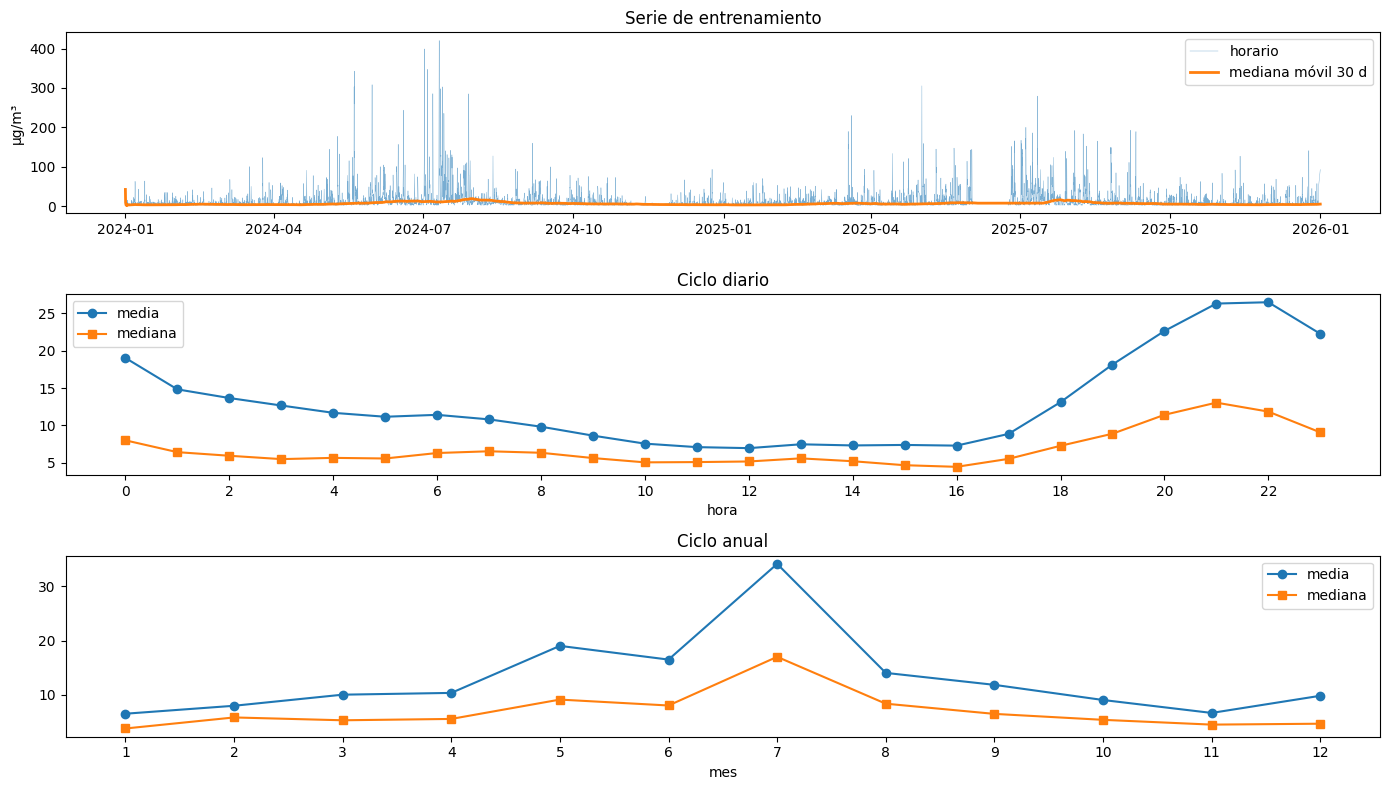

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

axes[0].plot(y_train.index, y_train, lw=0.3, alpha=0.6, label='horario')
axes[0].plot(y_train.index, y_train.rolling('30D').median(), c='C1', lw=2, label='mediana móvil 30 d')
axes[0].set_title('Serie de entrenamiento'); axes[0].set_ylabel('µg/m³'); axes[0].legend()

ciclo_h = y_train.groupby(y_train.index.hour).agg(['mean', 'median'])
axes[1].plot(ciclo_h.index, ciclo_h['mean'], marker='o', label='media')
axes[1].plot(ciclo_h.index, ciclo_h['median'], marker='s', label='mediana')
axes[1].set_title('Ciclo diario'); axes[1].set_xlabel('hora'); axes[1].set_xticks(range(0, 24, 2)); axes[1].legend()

ciclo_m = y_train.groupby(y_train.index.month).agg(['mean', 'median'])
axes[2].plot(ciclo_m.index, ciclo_m['mean'], marker='o', label='media')
axes[2].plot(ciclo_m.index, ciclo_m['median'], marker='s', label='mediana')
axes[2].set_title('Ciclo anual'); axes[2].set_xlabel('mes'); axes[2].set_xticks(range(1, 13)); axes[2].legend()

plt.tight_layout(); plt.show()

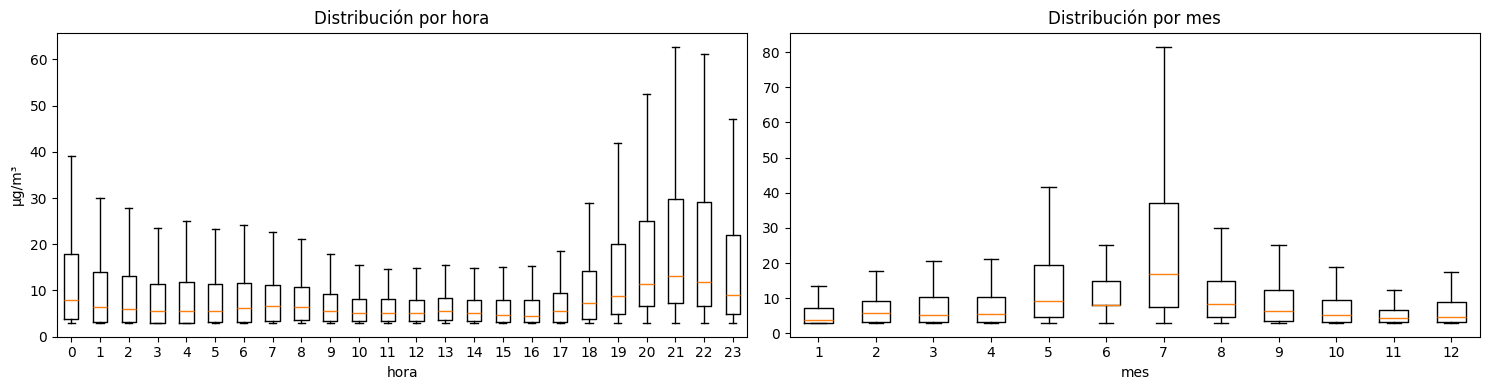

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
d = y_train.dropna()
axes[0].boxplot([d[d.index.hour == h].values for h in range(24)], labels=range(24), showfliers=False)
axes[0].set_title('Distribución por hora'); axes[0].set_xlabel('hora'); axes[0].set_ylabel('µg/m³')
axes[1].boxplot([d[d.index.month == m].values for m in range(1, 13)], labels=range(1, 13), showfliers=False)
axes[1].set_title('Distribución por mes'); axes[1].set_xlabel('mes')
plt.tight_layout(); plt.show()

### 8.2 Estacionariedad

**No es lo mismo que estacionalidad.** La estacionalidad es repetición; la estacionariedad es que las propiedades estadísticas (media, varianza) se mantengan **estables** en el tiempo.

**Por qué se revisa.** El modelo aprende en el pasado una relación entre rezagos y valor futuro. Si el nivel o la dispersión cambian continuamente, ese patrón deja de representar al período a pronosticar. No es requisito estricto para árboles ni skforecast, pero una tendencia fuerte complica la generalización porque los árboles no extrapolan fuera del rango que vieron.

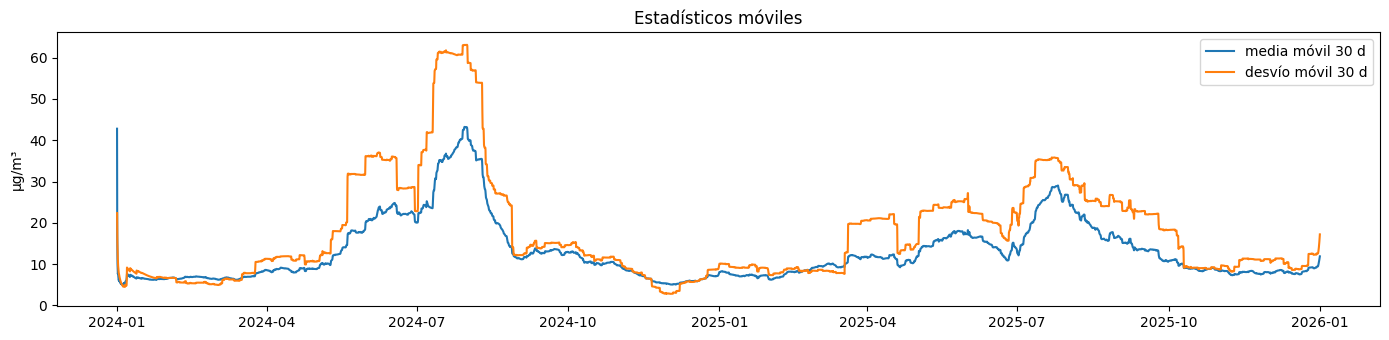

,desde,hasta,media,std,mediana,p95
tramo 1,2024-01-01,2024-07-01,11.75,19.69,6.08,40.66
tramo 2,2024-07-01,2024-12-31,14.9,30.15,6.52,52.77
tramo 3,2024-12-31,2025-07-02,11.97,18.72,7.49,39.92
tramo 4,2025-07-02,2025-12-31,13.49,21.23,6.2,49.87


In [ ]:
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(y_train.index, y_train.rolling('30D').mean(), label='media móvil 30 d')
ax.plot(y_train.index, y_train.rolling('30D').std(), label='desvío móvil 30 d')
ax.set_title('Estadísticos móviles'); ax.set_ylabel('µg/m³'); ax.legend()
plt.tight_layout(); plt.show()

tramos = [y_train.iloc[i] for i in np.array_split(np.arange(len(y_train)), 4)]
pd.DataFrame({f'tramo {i+1}': {'desde': t.index.min().date(), 'hasta': t.index.max().date(),
                               'media': round(t.mean(), 2), 'std': round(t.std(), 2),
                               'mediana': round(t.median(), 2), 'p95': round(t.quantile(0.95), 2)}
              for i, t in enumerate(tramos)}).T

In [ ]:
# ADF: H0 = hay raíz unitaria (no estacionaria). p < 0.05 → se rechaza → estacionaria
adf = adfuller(y_train.dropna(), autolag='AIC')
print(f'ADF   estadístico = {adf[0]:.3f} | p-valor = {adf[1]:.4f}')
print('  →', 'estacionaria' if adf[1] < 0.05 else 'no estacionaria')

# KPSS: H0 = es estacionaria (al revés que ADF). p < 0.05 → se rechaza → NO estacionaria
kp = kpss(y_train.dropna(), regression='c', nlags='auto')
print(f'\nKPSS  estadístico = {kp[0]:.3f} | p-valor = {kp[1]:.4f}')
print('  →', 'no estacionaria' if kp[1] < 0.05 else 'estacionaria')

ADF   estadístico = -11.160 | p-valor = 0.0000
  → estacionaria

KPSS  estadístico = 0.593 | p-valor = 0.0233
  → no estacionaria


**Cómo leerlas juntas.** Tienen hipótesis nulas **opuestas**:

| ADF | KPSS | Conclusión |
|---|---|---|
| rechaza | no rechaza | Estacionaria |
| no rechaza | rechaza | No estacionaria |
| rechaza | rechaza | Estacionaria en tendencia o cambio estructural |
| no rechaza | no rechaza | Poca información; mirar los gráficos |

Recordar que la serie tiene ciclo anual fuerte: una serie con estacionalidad marcada puede cambiar de media según el momento del ciclo sin que eso sea un problema a corregir con diferenciación. Se puede modelar con lags y variables de calendario.

### 8.3 Autocorrelación: ACF y PACF

**ACF** mide cuánto se parece la serie a sí misma desplazada *k* pasos.

**PACF** mide esa misma relación **descontando los rezagos intermedios**. Ejemplo: la hora actual se parece a la de hace 2 horas en buena parte *porque* ambas se parecen a la de hace 1 hora; la PACF quita ese efecto indirecto y muestra el aporte propio del lag 2.

**Para qué sirven:** orientar qué rezagos incluir. Picos en múltiplos de 24 sugieren lags 24, 48, 168.

**Para qué no:** no eligen los lags por sí solas. La decisión final se comprueba con backtesting.

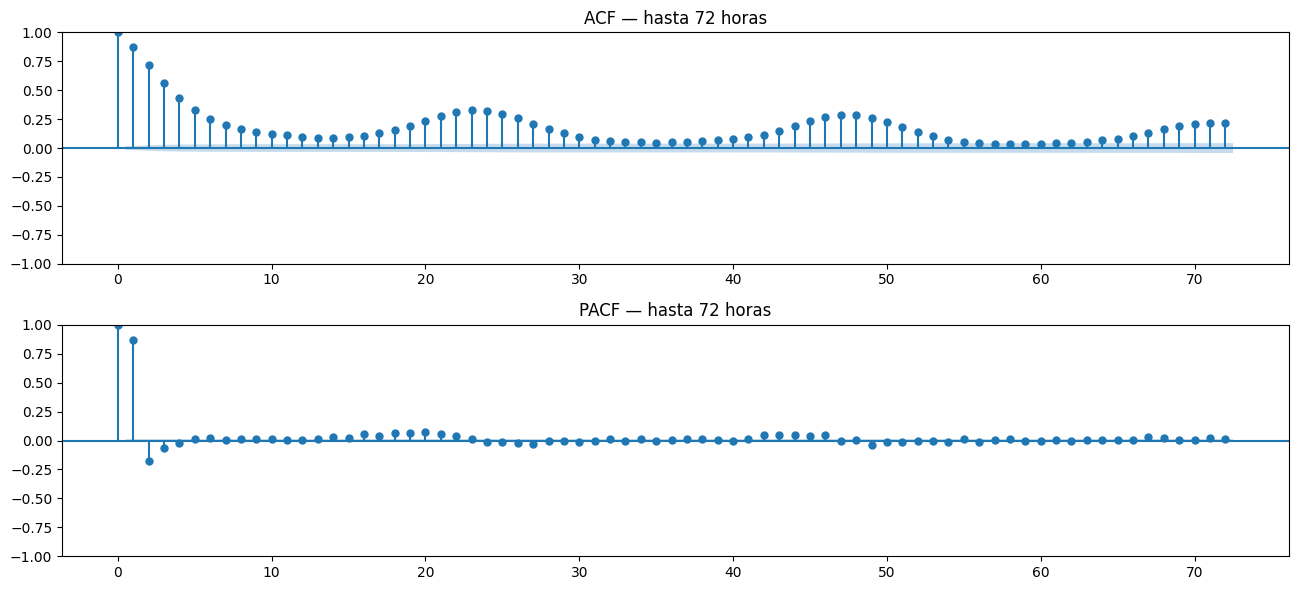

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6))
plot_acf(y_train.dropna(), lags=72, ax=axes[0]); axes[0].set_title('ACF — hasta 72 horas')
plot_pacf(y_train.dropna(), lags=72, ax=axes[1], method='ywm'); axes[1].set_title('PACF — hasta 72 horas')
plt.tight_layout(); plt.show()

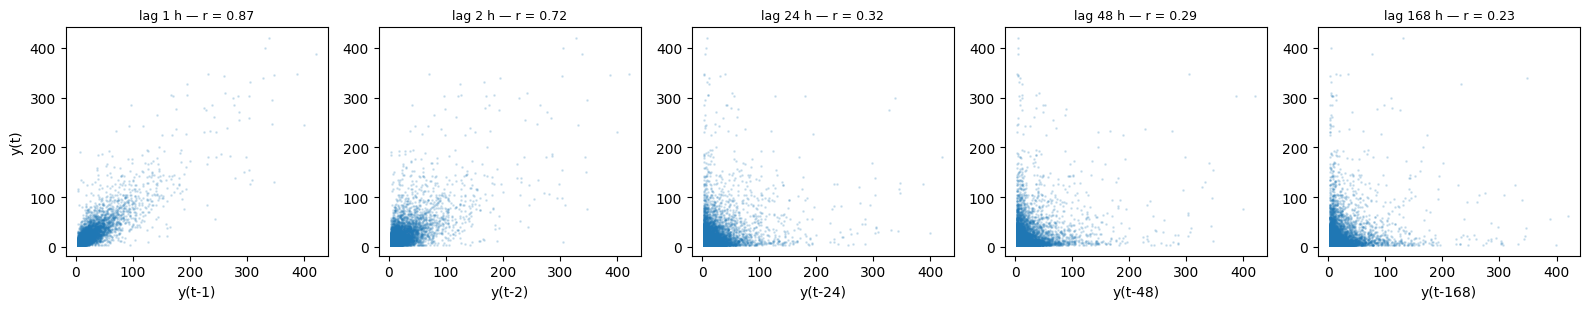

In [ ]:
LAGS = [1, 2, 24, 48, 168]
fig, axes = plt.subplots(1, len(LAGS), figsize=(16, 3.2))
for ax, lag in zip(axes, LAGS):
    ax.scatter(y_train.shift(lag), y_train, s=1, alpha=0.15)
    ax.set_title(f'lag {lag} h — r = {y_train.corr(y_train.shift(lag)):.2f}', fontsize=9)
    ax.set_xlabel(f'y(t-{lag})')
axes[0].set_ylabel('y(t)')
plt.tight_layout(); plt.show()

### 8.4 Comparación entre estaciones

Importa para la validación espacial: si las estaciones miden niveles sistemáticamente distintos, un modelo entrenado en Maroñas va a tener un sesgo constante en Museo Romántico.

Correlación horaria entre estaciones: 0.584
Diferencia media (Maroñas - Museo): 2.91 µg/m³


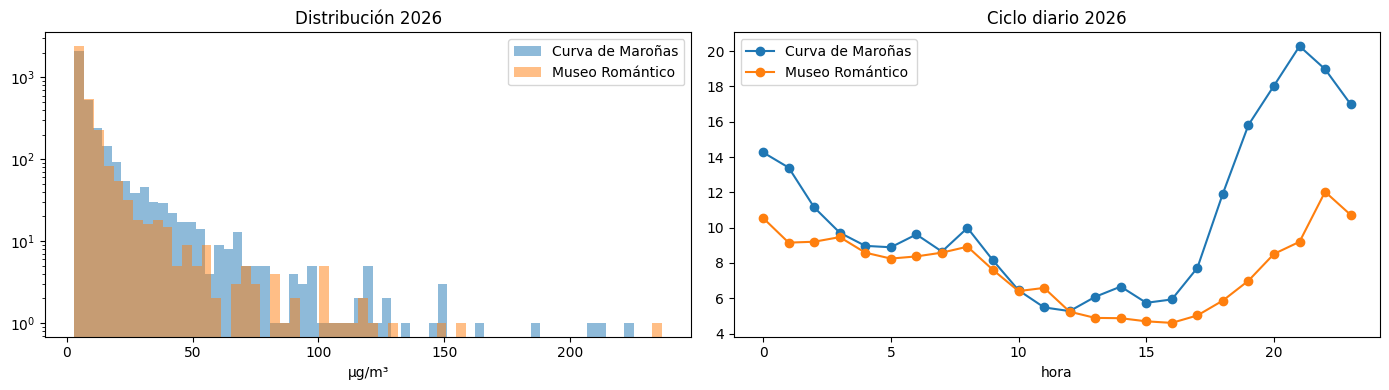

In [ ]:
comun = df_h[df_h.index >= FIN_TRAIN]
pivot = comun.pivot_table(index=comun.index, columns='estacion', values='pm25')
print('Correlación horaria entre estaciones:', round(pivot.corr().iloc[0, 1], 3))
print('Diferencia media (Maroñas - Museo):',
      round((pivot['Curva de Maroñas'] - pivot['Museo Romántico']).mean(), 2), 'µg/m³')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for est in ESTACIONES:
    s = comun[comun.estacion == est].pm25.dropna()
    axes[0].hist(s, bins=60, alpha=0.5, label=est, log=True)
    axes[1].plot(s.groupby(s.index.hour).mean(), marker='o', label=est)
axes[0].set_title('Distribución 2026'); axes[0].set_xlabel('µg/m³')
axes[1].set_title('Ciclo diario 2026'); axes[1].set_xlabel('hora')
for a in axes: a.legend()
plt.tight_layout(); plt.show()

## 9. Exportación

Se toma el PM2.5 horario, se agregan las variables de calendario (conocidas a futuro, sin riesgo de fuga) y se marca la partición.

**Lo que NO se hace acá:** escalado ni codificación aprendida. Estiman parámetros de los datos, así que van dentro del pipeline del modelo para poder ajustarse con el entrenamiento de cada fold del backtesting.

In [ ]:
df = df_h.copy()   # solo PM2.5: el modelo base es univariante

df['hora'] = df.index.hour
df['dia_semana'] = df.index.dayofweek
df['mes'] = df.index.month
UMBRAL_EVALUABLE = 0.75
df['evaluable'] = (df.completitud_observada >= UMBRAL_EVALUABLE) & ~df.get('fuera_rango_valido', False)
df['particion'] = np.select(
    [(df.estacion == 'Curva de Maroñas') & (df.index < FIN_TRAIN),
     (df.estacion == 'Curva de Maroñas') & (df.index >= FIN_TRAIN),
     df.estacion == 'Museo Romántico'],
    ['entrenamiento', 'validacion_temporal', 'validacion_espacial'], default='')

display(df.groupby('particion').agg(
    horas=('pm25', 'size'), nan=('pm25', lambda s: s.isna().sum()),
    evaluables=('evaluable', 'sum'),
    pct_evaluable=('evaluable', lambda s: round(100 * s.mean(), 1)),
    media=('pm25', 'mean'), desvio=('pm25', 'std')).round(2))

SALIDA = 'pm25_horario_preprocesado.csv'   # se descarga a la carpeta local de Colab
df.reset_index().rename(columns={'index': 'timestamp'}).to_csv(SALIDA, index=False)
print(f'\nGuardado: {SALIDA}')
print(f'{len(df)} filas · {df.shape[1]} columnas')
print('Columnas:', list(df.columns))

,horas,nan,evaluables,pct_evaluable,media,desvio
particion,,,,,,
entrenamiento,17544,0,16296,92.9,13.03,22.94
validacion_espacial,3480,0,3451,99.2,7.68,11.77
validacion_temporal,3480,0,3476,99.9,10.59,16.66



Guardado: pm25_horario_preprocesado.csv
24504 filas · 9 columnas
Columnas: ['pm25', 'completitud_observada', 'estacion', 'fuera_rango_valido', 'hora', 'dia_semana', 'mes', 'evaluable', 'particion']


### Horas evaluables

Los valores imputados sirven como **entrada** del modelo: alimentan los lags y mantienen el índice sin agujeros. Pero no sirven como **objetivo** al calcular el error, porque no son una medición: son un número que produjimos con una interpolación. Comparar la predicción contra ellos mide cuánto se parece el modelo a nuestra propia imputación, no a la realidad.

Por eso se marca cada hora con una bandera `evaluable`, y las métricas finales se calculan solo sobre esas horas. Es el criterio de Rakholia et al. (2022), p. 3, que registra los pares cuyo objetivo contiene un valor imputado para asegurar que solo se usen pares con valores reales al evaluar un modelo entrenado.

## Resumen de decisiones

| Decisión | Qué se hizo | Justificación |
|---|---|---|
| Zona horaria | America/Montevideo en ambas fuentes | UTC-3 fijo; evita desalineación al unir |
| Faltantes | Se distinguen explícitos e implícitos | Contar solo NaN subestima el problema |
| Orden | Outliers → imputación → agregación | Imputar antes contamina con picos espurios; agregar antes los vuelve invisibles |
| Outliers de validez | Filtro de Hampel a resolución minutal (31 min, k=6, piso 300) + rango válido horario 0-500 µg/m³ | El rango es de Rakholia et al. (2022), p. 3. El filtro local sigue la lógica de Zhong et al. (2021) pero con mediana y MAD en vez de media móvil, y se aplica antes de agregar. El IQR queda descartado: marca 11 %, incluyendo contaminación real |
| Outliers contextuales | Se conservan | Son el evento que interesa pronosticar |
| Criterio de descarte | Forma temporal (tiempo de subida y ancho a media altura), no altura del pico | Un error del sensor sube y baja en 1-2 minutos; una pluma real tiene subida y caída graduales |
| Imputación | Lineal en todos los huecos | Gana el benchmark de error en todas las longitudes y es la que menos cambia la distribución |
| Cobertura | Se completa el 100 % de los huecos | Se guarda `completitud_observada` para filtrar si hace falta |
| Agregación | Horaria, ventana cerrada a izquierda | Evita fuga: ninguna fila contiene información posterior a su etiqueta |
| Evaluación | Solo horas con ≥75 % de mediciones reales (`evaluable`) | No se mide el error contra valores que produjo nuestra propia imputación; criterio de Rakholia et al. (2022), p. 3 |
| Orden del filtro | Se filtra sobre serie minutal, antes de agregar | Un pico de dos minutos no desaparece al promediar: levanta el valor horario. Rakholia promedia primero y no puede evitarlo |
| Meteorología en el criterio | No se usa | El viento no distingue los picos marcados del resto (punto 4.5), y una excepción aplicada solo a algunos casos no sería un criterio uniforme |
| Escalado | No se hace acá | Aprende parámetros; va en el pipeline por fold |
| Alcance | Solo PM2.5, sin exógenas | El modelo base es univariante; la meteorología se incorpora en una versión posterior |

### Limitaciones a declarar

1. **Sin variables meteorológicas.** Esta versión prepara únicamente la serie de PM2.5. Cuando se incorporen exógenas habrá que declarar que usar valores observados en lugar de pronósticos da un escenario oráculo, o sea una cota superior optimista.
2. **Instrumento no identificado.** No se dispone del modelo ni de la especificación técnica de los analizadores, así que el umbral de validez no pudo fijarse a partir del rango del equipo. Se adoptó en su lugar el criterio publicado en Rakholia et al. (2022), p. 3.
3. **Eventos no predecibles.** Los episodios de combustión local (quemas, incendios) no son anticipables con las variables exógenas disponibles. Se conservan en los datos y su error se reporta por separado del régimen normal, en lugar de excluirlos.
4. **Tramos largos imputados.** En huecos de días, el error de la mejor imputación disponible es del orden del nivel medio de la serie: esos tramos son ruido, no información.
5. **Censura por la izquierda.** Buena parte de las mediciones está en el piso de detección del sensor.
6. **Sesgo estacional en las particiones de 2026.** Cubren enero a mayo, sin invierno, que es la estación de mayor contaminación.
7. **Diferencia de nivel entre estaciones.** Un modelo entrenado en Maroñas tenderá a sobrepredecir en Museo Romántico.
8. **Ventana centrada en el filtro de outliers.** Admisible para reconstruir una base histórica; en producción sería una ventana solo hacia atrás.

### Referencia

Rakholia, R., Le, Q., Vu, K., Ho, B. Q., y Carbajo, R. S. (2022). AI-based air quality PM2.5 forecasting models for developing countries: A case study of Ho Chi Minh City, Vietnam. *Urban Climate*, 46, 101315.